In [1]:
import pandas as pd

In [2]:
X_train = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/X_train.csv')
X_val   = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/X_val.csv')
X_test  = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/X_test.csv')
y_train = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/y_train.csv').squeeze()
y_val   = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/y_val.csv').squeeze()
y_test  = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/y_test.csv').squeeze()

In [3]:
print(X_train.shape)

(9899999, 28)


# Parameters found from RandomizedSearchCV

Best params:  
  subsample: 0.9    
  reg_lambda: 1   
  reg_alpha: 0.1    
  n_estimators: 500   
  min_child_weight: 3   
  max_depth: 8    
  learning_rate: 0.1    
  gamma: 0    
  colsample_bytree: 0.7   
  
Best CV AUC: 0.8388   
Validation AUC: 0.8390  

In [4]:
#Training XGBoost on diff sizes of dataset (Learning curve)
import time
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


sizes = [10000, 50000, 100000, 250000, 500000, 1000000, 2500000, 5000000]

auc_score = []
best_iterations = []
training_times = []

for size in sizes:
    
    indices = X_train.sample(n=size, random_state=42).index

    X_train_sample = X_train.loc[indices]
    y_train_sample = y_train.loc[indices]

    xgb_tuned = XGBClassifier(
        subsample=0.9,
        reg_lambda=1,
        reg_alpha=0.1,
        n_estimators=10000,
        min_child_weight=3,
        max_depth=8,
        learning_rate=0.1,
        gamma=0,
        colsample_bytree=0.7,
        early_stopping_rounds=50,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        device='cuda'
    )

    start_time = time.time()
    
    xgb_tuned.fit(
    X_train_sample,
    y_train_sample,
    eval_set=[(X_val, y_val)],
    verbose=False)

    training_time = time.time() - start_time

    auc = roc_auc_score(y_val, xgb_tuned.predict_proba(X_val)[:, 1])
    
    auc_score.append(auc)
    best_iterations.append(xgb_tuned.best_iteration)
    training_times.append(training_time)
    
    print(f"Size: {size}, AUC: {auc:.4f}, Best_Iteration: {xgb_tuned.best_iteration}, Time: {training_time:.2f} sec")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:57:16] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Size: 10000, AUC: 0.7823, Best_Iteration: 55, Time: 1.82 sec
Size: 50000, AUC: 0.8054, Best_Iteration: 108, Time: 1.48 sec
Size: 100000, AUC: 0.8131, Best_Iteration: 190, Time: 2.21 sec
Size: 250000, AUC: 0.8219, Best_Iteration: 413, Time: 4.58 sec
Size: 500000, AUC: 0.8289, Best_Iteration: 577, Time: 7.44 sec
Size: 1000000, AUC: 0.8350, Best_Iteration: 1034, Time: 16.67 sec
Size: 2500000, AUC: 0.8430, Best_Iteration: 2261, Time: 64.08 sec
Size: 5000000, AUC: 0.8488, Best_Iteration: 3526, Time: 194.73 sec


As the training size increased from 10,000 to 5,000,000 events, the validation AUC steadily increased. The largest gains are at the smaller data set sizes, with improvements tapering off beyond one million events. This indicates that modern XGBoost can extract most discriminative information from a fraction of the available HIGGS dataset, although more data still provides incremental improvements.

In [5]:
learning_curve_results = pd.DataFrame({
    "Training Size": sizes,
    "AUC": auc_score,
    "Best Iterations": best_iterations,
    "Training Time (sec)": training_times
})

learning_curve_results["AUC Gain"] = learning_curve_results["AUC"].diff()

learning_curve_results

,Training Size,AUC,Best Iterations,Training Time (sec),AUC Gain
0,10000,0.782333,55,1.823531,NaN
1,50000,0.805421,108,1.475551,0.023087
2,100000,0.813080,190,2.207243,0.007659
3,250000,0.821936,413,4.575684,0.008856
4,500000,0.828882,577,7.442126,0.006945
5,1000000,0.834993,1034,16.674511,0.006111
6,2500000,0.843019,2261,64.083215,0.008026
7,5000000,0.848819,3526,194.734479,0.005801


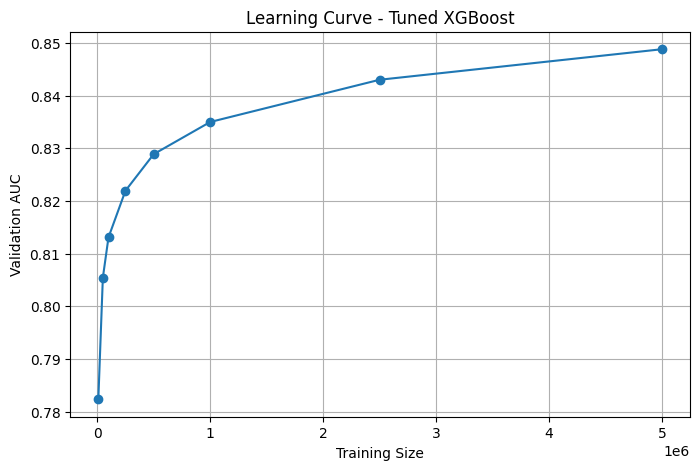

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(sizes, auc_score, marker='o')

plt.xlabel("Training Size")
plt.ylabel("Validation AUC")
plt.title("Learning Curve - Tuned XGBoost")
plt.grid(True)
plt.show()

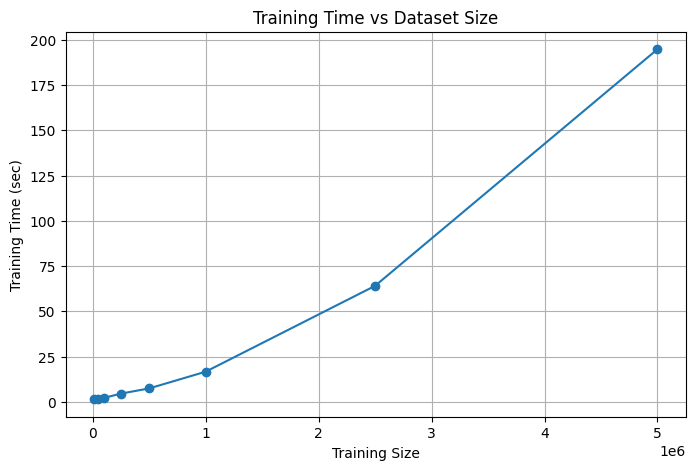

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(sizes, training_times, marker='o')

plt.xlabel("Training Size")
plt.ylabel("Training Time (sec)")
plt.title("Training Time vs Dataset Size")
plt.grid(True)
plt.show()

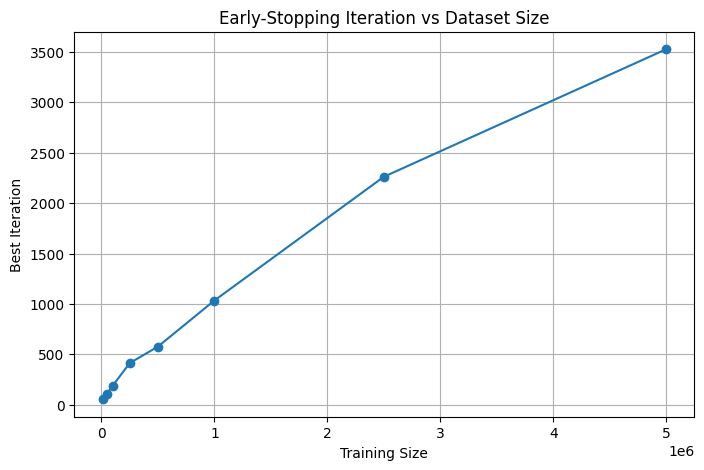

In [10]:
plt.figure(figsize=(8,5))

plt.plot(sizes, best_iterations, marker='o')

plt.xlabel("Training Size")
plt.ylabel("Best Iteration")
plt.title("Early-Stopping Iteration vs Dataset Size")
plt.grid(True)
plt.show()